# Generate VAR Data

This notebook creates grouped synthetic time-series data for the `Infer-Effective-Connection` workflow. The group-level dynamics follow the sparse VAR example used in Tank et al., *Neural Granger Causality*: sparse VAR(1) or VAR(2), self dependencies plus randomly selected additional causes per target, initial nonzero coefficients `beta_value = 1.0`, and stationary rescaling with companion-matrix radius `0.97`.

The project consumes `generated_data.npz` files with at least:

- `data`: observed time series with shape `(T, total_observed_variables)`
- `group`: observed-variable counts for each group

Additional arrays save the VAR ground truth for later causal-graph evaluation.


In [21]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root():
    cwd = Path.cwd().resolve()
    for base in (cwd, *cwd.parents):
        if (base / "NIS_macro.py").exists() and (base / "src").exists():
            return base
        project = base / "Infer-Effective-Connection"
        if (project / "NIS_macro.py").exists() and (project / "src").exists():
            return project
    raise FileNotFoundError("Could not locate the Infer-Effective-Connection project root.")


PROJECT_ROOT = find_project_root()
OUTPUT_DIR = PROJECT_ROOT / "loc_data_var"
OUTPUT_PATH = OUTPUT_DIR / "generated_data.npz"

CONFIG = {
    "num_groups": 10,
    "time_steps": 2000,
    "var_lag": 2,
    "num_extra_causes": 1,
    "beta_value": 1.0,
    "stationary_radius": 0.97,
    "noise_scale": 0.0001,
    "initial_state_scale": 0.1,
    "burn_in": 100,
    "avg_vars_per_group": 4,
    "min_vars_per_group": 2,
    "measurement_noise_scale": 0.01,
}

print(f"project_root: {PROJECT_ROOT}")
print(f"output_path: {OUTPUT_PATH}")
CONFIG

project_root: /home/wangzhipeng/code/causal_network/causal_network/lorzen/Infer-Effective-Connection
output_path: /home/wangzhipeng/code/causal_network/causal_network/lorzen/Infer-Effective-Connection/loc_data_var/generated_data.npz


{'num_groups': 10,
 'time_steps': 2000,
 'var_lag': 2,
 'num_extra_causes': 1,
 'beta_value': 1.0,
 'stationary_radius': 0.97,
 'noise_scale': 0.0001,
 'initial_state_scale': 0.1,
 'burn_in': 100,
 'avg_vars_per_group': 4,
 'min_vars_per_group': 2,
 'measurement_noise_scale': 0.01}

## VAR And Observation Generators

The VAR coefficients use rows as targets and columns as sources: `A[k, i, j] != 0` means source group `j` Granger-causes target group `i` at lag `k + 1`.


In [22]:
def standardize_rows(values, eps=1e-8):
    values = np.asarray(values, dtype=np.float32)
    mean = values.mean(axis=1, keepdims=True)
    std = values.std(axis=1, keepdims=True)
    return (values - mean) / (std + eps)


def companion_spectral_radius(beta):
    beta = np.asarray(beta, dtype=np.float64)
    num_groups = beta.shape[0]
    var_lag = beta.shape[1] // num_groups
    if beta.shape[1] != num_groups * var_lag or var_lag < 1:
        raise ValueError("beta must have shape (num_groups, num_groups * var_lag)")
    if var_lag == 1:
        companion = beta
    else:
        bottom = np.hstack(
            (
                np.eye(num_groups * (var_lag - 1)),
                np.zeros((num_groups * (var_lag - 1), num_groups)),
            )
        )
        companion = np.vstack((beta, bottom))
    return float(np.max(np.abs(np.linalg.eigvals(companion))))


def make_var_stationary(beta, radius=0.97, shrink_factor=0.95):
    beta = np.asarray(beta, dtype=np.float64).copy()
    while companion_spectral_radius(beta) > radius:
        beta *= shrink_factor
    return beta.astype(np.float32)


def make_sparse_var_coefficients(
    num_groups,
    var_lag,
    num_extra_causes,
    beta_value,
    stationary_radius,
):
    rng = np.random.default_rng()
    base_beta = np.eye(num_groups, dtype=np.float32) * beta_value
    causal_matrix = np.eye(num_groups, dtype=np.float32)

    for target in range(num_groups):
        candidates = np.array([source for source in range(num_groups) if source != target])
        extra_sources = rng.choice(candidates, size=num_extra_causes, replace=False)
        causal_matrix[target, extra_sources] = 1.0
        base_beta[target, extra_sources] = beta_value

    beta = np.hstack([base_beta.copy() for _ in range(var_lag)])
    beta = make_var_stationary(beta, radius=stationary_radius)
    coef_matrices = np.stack(
        [beta[:, lag_index * num_groups : (lag_index + 1) * num_groups] for lag_index in range(var_lag)],
        axis=0,
    ).astype(np.float32)
    return coef_matrices, causal_matrix


def simulate_sparse_var(time_steps, coef_matrices, noise_scale, initial_state_scale, burn_in):
    rng = np.random.default_rng()
    var_lag, num_groups, _ = coef_matrices.shape
    total_steps = time_steps + burn_in
    states = np.zeros((total_steps + var_lag, num_groups), dtype=np.float32)
    noise = rng.normal(0.0, noise_scale, size=states.shape).astype(np.float32)
    states[:var_lag] = rng.normal(
        0.0,
        initial_state_scale,
        size=(var_lag, num_groups),
    ).astype(np.float32)

    for t in range(var_lag, total_steps + var_lag):
        predicted = np.zeros(num_groups, dtype=np.float32)
        for lag_index in range(var_lag):
            predicted += coef_matrices[lag_index] @ states[t - lag_index - 1]
        states[t] = predicted + noise[t]

    return states[burn_in + var_lag :]


def make_group_sizes(num_groups, avg_vars_per_group, min_vars_per_group):
    if avg_vars_per_group < min_vars_per_group:
        raise ValueError("avg_vars_per_group must be >= min_vars_per_group")
    if min_vars_per_group % 2 != 0:
        raise ValueError("min_vars_per_group must be even")

    rng = np.random.default_rng()
    total_vars = int(num_groups * avg_vars_per_group)
    if total_vars % 2 != 0:
        raise ValueError("num_groups * avg_vars_per_group must be even")

    base_total = int(num_groups * min_vars_per_group)
    extra = total_vars - base_total
    if extra < 0 or extra % 2 != 0:
        raise ValueError("remaining variables after the minimum allocation must be a nonnegative even number")

    increments = 2 * rng.multinomial(extra // 2, np.ones(num_groups) / num_groups)
    return (min_vars_per_group + increments).astype(np.int32)


def generate_observed_groups(
    Y_true,
    group_sizes,
    measurement_noise_scale,
):
    rng = np.random.default_rng()
    num_groups, time_steps = Y_true.shape
    total_observed = int(group_sizes.sum())
    observed_groups = []
    measurement_matrix = np.zeros((total_observed, num_groups), dtype=np.float32)
    group_ids = np.zeros(total_observed, dtype=np.int32)

    row = 0
    for group_idx, group_size in enumerate(group_sizes):
        weights = rng.normal(loc=1.0, scale=0.5, size=int(group_size)).astype(np.float32)
        weights = weights / (np.linalg.norm(weights) + 1e-8)
        
        group_data = weights[:, None] * Y_true[group_idx][None, :]
        group_data += rng.normal(
            0.0,
            measurement_noise_scale,
            size=(int(group_size), time_steps),
        ).astype(np.float32)
        group_data = standardize_rows(group_data)
        
        observed_groups.append(group_data)
        stop = row + int(group_size)
        measurement_matrix[row:stop, group_idx] = weights
        group_ids[row:stop] = group_idx
        row = stop

    data = np.concatenate(observed_groups, axis=0).T.astype(np.float32)
    return data, observed_groups, measurement_matrix, group_ids


def save_var_dataset(
    output_path,
    data,
    group_sizes,
    Y_true,
    Y_var_raw,
    coef_matrices,
    causal_matrix,
    measurement_matrix,
    group_ids,
    config,
):
    output_path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        output_path,
        data=data.astype(np.float32),
        group=group_sizes.astype(np.int32),
        Y_true=Y_true.astype(np.float32),
        Y_var_raw=Y_var_raw.astype(np.float32),
        coef_matrices=coef_matrices.astype(np.float32),
        causal_matrix=causal_matrix.astype(np.float32),
        measurement_matrix=measurement_matrix.astype(np.float32),
        group_ids=group_ids.astype(np.int32),
        config_json=np.array(json.dumps(config, sort_keys=True)),
    )


## Generate And Save

Defaults follow the VAR(2), `T = 1000` setting from the paper's VAR experiment. Change `CONFIG["var_lag"]` to `1` for the VAR(1) case.

For deterministic runs, `noise_scale = 0` removes process noise but does not have to make the sequence zero. `initial_state_scale` controls the nonzero initial state separately. Because a stable VAR without process noise decays toward zero, use `burn_in = 0` when you want to keep that deterministic transient in the saved data.


In [23]:
coef_matrices, causal_matrix = make_sparse_var_coefficients(
    num_groups=CONFIG["num_groups"],
    var_lag=CONFIG["var_lag"],
    num_extra_causes=CONFIG["num_extra_causes"],
    beta_value=CONFIG["beta_value"],
    stationary_radius=CONFIG["stationary_radius"],
)

Y_var_raw = simulate_sparse_var(
    time_steps=CONFIG["time_steps"],
    coef_matrices=coef_matrices,
    noise_scale=CONFIG["noise_scale"],
    initial_state_scale=CONFIG["initial_state_scale"],
    burn_in=CONFIG["burn_in"],
)

Y_true = standardize_rows(Y_var_raw.T)
group_sizes = make_group_sizes(
    num_groups=CONFIG["num_groups"],
    avg_vars_per_group=CONFIG["avg_vars_per_group"],
    min_vars_per_group=CONFIG["min_vars_per_group"],
)

data, observed_groups, measurement_matrix, group_ids = generate_observed_groups(
    Y_true=Y_true,
    group_sizes=group_sizes,
    measurement_noise_scale=CONFIG["measurement_noise_scale"],
)

save_var_dataset(
    output_path=OUTPUT_PATH,
    data=data,
    group_sizes=group_sizes,
    Y_true=Y_true,
    Y_var_raw=Y_var_raw.T,
    coef_matrices=coef_matrices,
    causal_matrix=causal_matrix,
    measurement_matrix=measurement_matrix,
    group_ids=group_ids,
    config=CONFIG,
)

summary = {
    "data_shape": tuple(data.shape),
    "group_count": int(len(group_sizes)),
    "total_observed_variables": int(group_sizes.sum()),
    "group_sizes": group_sizes.tolist(),
    "var_lag": CONFIG["var_lag"],
    "stationary_radius": companion_spectral_radius(np.hstack([coef_matrices[k] for k in range(CONFIG["var_lag"])])),
    "edges_including_self": int(causal_matrix.sum()),
    "off_diagonal_edges": int(causal_matrix.sum() - CONFIG["num_groups"]),
    "saved_to": str(OUTPUT_PATH),
}

print(json.dumps(summary, indent=2))


{
  "data_shape": [
    2000,
    40
  ],
  "group_count": 10,
  "total_observed_variables": 40,
  "group_sizes": [
    2,
    2,
    8,
    2,
    6,
    6,
    2,
    6,
    4,
    2
  ],
  "var_lag": 2,
  "stationary_radius": 0.9673578250423797,
  "edges_including_self": 20,
  "off_diagonal_edges": 10,
  "saved_to": "/home/wangzhipeng/code/causal_network/causal_network/lorzen/Infer-Effective-Connection/loc_data_var/generated_data.npz"
}


## Quick Visual Check


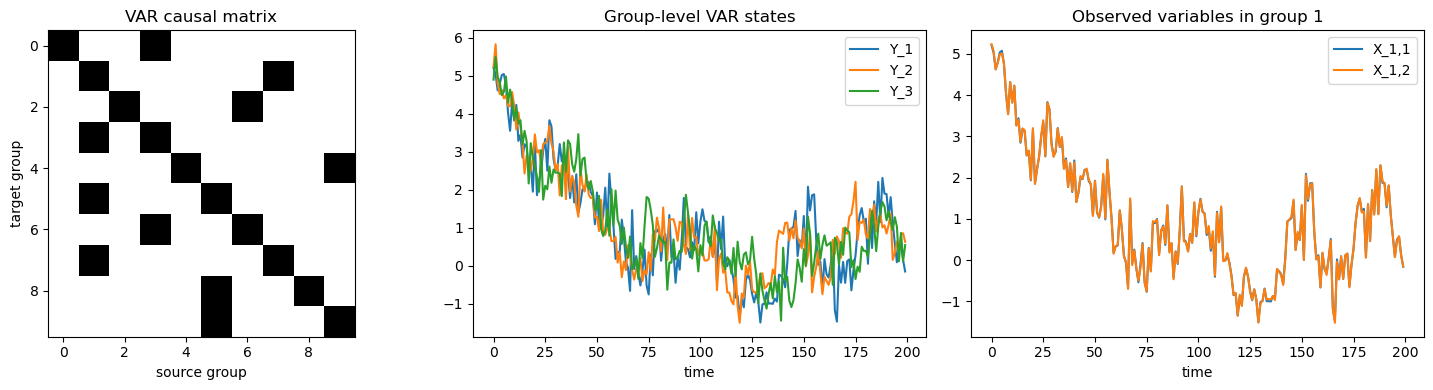

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(causal_matrix, cmap="Greys", vmin=0, vmax=1)
axes[0].set_title("VAR causal matrix")
axes[0].set_xlabel("source group")
axes[0].set_ylabel("target group")

for idx in range(min(3, CONFIG["num_groups"])):
    axes[1].plot(Y_true[idx, :200], label=f"Y_{idx + 1}")
axes[1].set_title("Group-level VAR states")
axes[1].set_xlabel("time")
axes[1].legend()

for idx in range(min(4, observed_groups[0].shape[0])):
    axes[2].plot(observed_groups[0][idx, :200], label=f"X_1,{idx + 1}")
axes[2].set_title("Observed variables in group 1")
axes[2].set_xlabel("time")
axes[2].legend()

plt.tight_layout()
plt.show()


## Contract Check

This checks the arrays that downstream training code expects.


In [25]:
with np.load(OUTPUT_PATH, allow_pickle=False) as archive:
    loaded_data = archive["data"]
    loaded_group = archive["group"]
    loaded_causal = archive["causal_matrix"]
    loaded_coef = archive["coef_matrices"]

assert loaded_data.shape == (CONFIG["time_steps"], int(loaded_group.sum()))
assert loaded_group.shape == (CONFIG["num_groups"],)
assert loaded_causal.shape == (CONFIG["num_groups"], CONFIG["num_groups"])
assert loaded_coef.shape == (
    CONFIG["var_lag"],
    CONFIG["num_groups"],
    CONFIG["num_groups"],
)
assert np.allclose(np.diag(loaded_causal), 1.0)

pd.Series(
    {
        "data_rows": loaded_data.shape[0],
        "data_cols": loaded_data.shape[1],
        "group_sum": int(loaded_group.sum()),
        "num_groups": loaded_group.shape[0],
        "causal_edges_including_self": int(loaded_causal.sum()),
    }
)


data_rows                      2000
data_cols                        40
group_sum                        40
num_groups                       10
causal_edges_including_self      20
dtype: int64